In [ ]:
!pip install -q transformers accelerate pydantic outlines pandas numpy scipy scikit-learn gdown

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Interchangeable
RACHITA_PATH = "/content/drive/MyDrive/ECE 219 Project 3"
FARRAH_PATH = "/content/drive/MyDrive/ECE 219 Project 3"

DATA_DIR = FARRAH_PATH # switch this

In [ ]:
import os

TARGET = "da-dev-tables"

matches = []
for dirpath, dirnames, filenames in os.walk(DATA_DIR):
    if TARGET in dirnames:
        matches.append(os.path.join(dirpath, TARGET))

print("Matches found:", len(matches))
for m in matches[:20]:
    print(" -", m)

assert len(matches) > 0, (
    "Could not find a folder named 'da-dev-tables'.\n"
    "This usually means it is inside 'Shared drives' (Team Drives) OR your path is not MyDrive."
)

Matches found: 1
 - /content/drive/MyDrive/ECE 219 Project 3/share_data/da-dev-tables


In [ ]:
TABLES_DIR = sorted(matches, key=len)[0]
print("Using TABLES_DIR:", TABLES_DIR)

csvs = [f for f in os.listdir(TABLES_DIR) if f.lower().endswith(".csv")]
print("Num CSV files in TABLES_DIR:", len(csvs))

assert len(csvs) > 0, "TABLES_DIR exists but contains no CSVs. You might have selected the wrong folder."

Using TABLES_DIR: /content/drive/MyDrive/ECE 219 Project 3/share_data/da-dev-tables
Num CSV files in TABLES_DIR: 68


In [ ]:
!pip -q install gdown

import os, re

def drive_id_from_url(url: str) -> str:
    m = re.search(r"/file/d/([^/]+)", url)
    if m: return m.group(1)
    m = re.search(r"[?&]id=([^&]+)", url)
    if m: return m.group(1)
    raise ValueError(f"Could not extract file id from url: {url}")

def ensure_jsonl_not_html(path: str, nbytes: int = 5000):
    with open(path, "rb") as f:
        head = f.read(nbytes)
    head_l = head.lower()
    if b"<!doctype html" in head_l or b"<html" in head_l or b"drive.google.com" in head_l:
        raise ValueError(
            f"{path} looks like HTML (Drive viewer page), not JSONL.\n"
            "Fix: download with a direct file-id method (gdown / uc?id=...)."
        )

def download_drive_file(url_or_id: str, out_path: str):
    import gdown

    if "/" in url_or_id or "http" in url_or_id:
        file_id = drive_id_from_url(url_or_id)
    else:
        file_id = url_or_id

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    gdown.download(id=file_id, output=out_path, quiet=False)
    ensure_jsonl_not_html(out_path)
    print("Downloaded OK:", out_path)

QUESTIONS_DRIVE_URL = "https://drive.google.com/file/d/1FBEp08h4hETyCA6lw_2pcnWOEwqtFxCM/view?usp=sharing"
LABELS_DRIVE_URL = "https://drive.google.com/file/d/1BqzDjFWuubKyNrOu-HTrAQRCxp7Z_CKd/view?usp=sharing"

LOCAL_DIR = "/content/daeval"
QUESTIONS_PATH = f"{LOCAL_DIR}/da-dev-questions.jsonl"
LABELS_PATH    = f"{LOCAL_DIR}/da-dev-labels.jsonl"

download_drive_file(QUESTIONS_DRIVE_URL, QUESTIONS_PATH)
download_drive_file(LABELS_DRIVE_URL, LABELS_PATH)

Downloading...
From: https://drive.google.com/uc?id=1FBEp08h4hETyCA6lw_2pcnWOEwqtFxCM
To: /content/daeval/da-dev-questions.jsonl
100%|██████████| 218k/218k [00:00<00:00, 59.5MB/s]


Downloaded OK: /content/daeval/da-dev-questions.jsonl


Downloading...
From: https://drive.google.com/uc?id=1BqzDjFWuubKyNrOu-HTrAQRCxp7Z_CKd
To: /content/daeval/da-dev-labels.jsonl
100%|██████████| 23.7k/23.7k [00:00<00:00, 46.3MB/s]

Downloaded OK: /content/daeval/da-dev-labels.jsonl


###QUESTION 14:
Load da-dev-questions.jsonl and da-dev-labels.jsonl. Report:
- The number of questions and labels.
- The set of keys present in a question record (print one example).
- The set of keys present in a label record (print one example).


---

**Answer:**

- There are 257 questions and 257 labels
- The set of keys in a question are ['concepts', 'constraints', 'file_name', 'format', 'id', 'level', 'question']. Question example is in code result below.

- The set of keys in a label are ['common_answers', 'id']. Label example is in the code result below.

In [ ]:
import json

def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as e:
                raise ValueError(
                    f"JSON decode failed at line {i} of {path}.\n"
                    f"First 200 chars: {line[:200]}"
                ) from e
    return rows

questions = load_jsonl(QUESTIONS_PATH)
labels    = load_jsonl(LABELS_PATH)

print("Num questions:", len(questions))
print("Num labels:   ", len(labels))

print("\nQuestion keys:", sorted(questions[0].keys()))
print("Example question:\n", json.dumps(questions[0], indent=2)[:1500])

print("\nLabel keys:", sorted(labels[0].keys()))
print("Example label:\n", json.dumps(labels[0], indent=2)[:1500])

Num questions: 257
Num labels:    257

Question keys: ['concepts', 'constraints', 'file_name', 'format', 'id', 'level', 'question']
Example question:
 {
  "id": 0,
  "question": "Calculate the mean fare paid by the passengers.",
  "concepts": [
    "Summary Statistics"
  ],
  "constraints": "Calculate the mean fare using Python's built-in statistics module or appropriate statistical method in pandas. Rounding off the answer to two decimal places.",
  "format": "@mean_fare[mean_fare_value] where \"mean_fare_value\" is a floating-point number rounded to two decimal places.",
  "file_name": "test_ave.csv",
  "level": "easy"
}

Label keys: ['common_answers', 'id']
Example label:
 {
  "id": 0,
  "common_answers": [
    [
      "mean_fare",
      "34.65"
    ]
  ]
}


###QUESTION 15:
Pick 3 random question IDs. For each:
- Print the file name of the referenced CSV.
- Load the CSV with pandas and print df.shape, df.dtypes, and df.head(3).
- Print the corresponding question.


---

**Answer:**

3 Questions with CSV file name and corresponding question can be found in the code result below.

In [ ]:
import re

csv_set = set([f for f in os.listdir(TABLES_DIR) if f.lower().endswith(".csv")])

def detect_table_key_by_evidence(questions, csv_set, max_scan=800):
    counts = {}
    for q in questions[:max_scan]:
        for k, v in q.items():
            if isinstance(v, str) and v.lower().endswith(".csv") and v in csv_set:
                counts[k] = counts.get(k, 0) + 1
    if not counts:
        return None, counts
    best = max(counts, key=counts.get)
    return best, counts

TABLE_KEY, evidence = detect_table_key_by_evidence(questions, csv_set)
print("Evidence:", evidence)
print("Detected TABLE_KEY:", TABLE_KEY)

if TABLE_KEY is None:
    # Fallback: maybe they store a table id (like 123) which maps to "123.csv"
    # Let's print a few question records that have any table-ish fields.
    def show_tableish(q):
        out = {}
        for k,v in q.items():
            if any(s in k.lower() for s in ["table", "csv", "file", "path", "fname", "filename", "name"]):
                out[k] = v
        return out

    print("\nNo .csv filename field found. Showing table-ish fields from first 5 questions:")
    for q in questions[:5]:
        print(show_tableish(q))

Evidence: {'file_name': 257}
Detected TABLE_KEY: file_name


In [ ]:
import random
import pandas as pd

def detect_key(records, candidates):
    for k in candidates:
        if k in records[0]:
            return k
    return None

QID_KEY = detect_key(questions, ["id","qid","question_id","idx"])
QTEXT_KEY = detect_key(questions, ["question","query","prompt","text","nl_question"])

for q in random.sample(questions, 3):
    qid = q.get(QID_KEY)
    qtext = q.get(QTEXT_KEY)
    csv_name = q.get(TABLE_KEY)

    print("\n" + "="*90)
    print("qid:", qid)
    print("csv:", csv_name)
    print("question:", qtext)

    csv_path = os.path.join(TABLES_DIR, csv_name)
    df = pd.read_csv(csv_path)

    print("shape:", df.shape)
    print("dtypes:\n", df.dtypes)
    print(df.head(3))


qid: 338
csv: Zip_MedianSoldPricePerSqft_AllHomes.csv
question: 3. Is there a correlation between the size rank of a region and the median sold price per square foot? If yes, is it a positive or negative correlation?
shape: (5124, 9)
dtypes:
 RegionID                    int64
RegionName                  int64
City                       object
State                      object
Metro                      object
CountyName                 object
SizeRank                    int64
Month                      object
MedianSoldPricePerSqft    float64
dtype: object
   RegionID  RegionName        City State       Metro            CountyName  \
0     66133       20009  Washington    DC  Washington  District of Columbia   
1     66133       20009  Washington    DC  Washington  District of Columbia   
2     66133       20009  Washington    DC  Washington  District of Columbia   

   SizeRank    Month  MedianSoldPricePerSqft  
0        32  1996-04                     NaN  
1        32  1996-05     

### QUESTION 16:
Find 2 examples where the required format contains multiple answer slots (e.g.,
two or more @name[value] fields). Explain:
- How the dataset represents multi-part answers in the labels.
- How you plan to evaluate such answers automatically.

---

**Answer:**

Examples:
- qid: 6
  - required_format: @mean_fare_child[mean_fare], @mean_fare_teenager[mean_fare], @mean_fare_adult[mean_fare], @mean_fare_elderly[mean_fare], where "mean_fare" is a float number rounded to 2 decimal places.
  - question: Create a new column called "AgeGroup" that categorizes the passengers into four age groups: 'Child' (0-12 years old), 'Teenager' (13-19 years old), 'Adult' (20-59 years old), and 'Elderly' (60 years old and above). Then, calculate the mean fare for each age group.

  
- qid: 8
  - required_format: @mean_fare_class1[mean_fare], @median_fare_class1[median_fare], @std_dev_fare_class1[std_dev], @mean_fare_class2[mean_fare], @median_fare_class2[median_fare], @std_dev_fare_class2[std_dev], @mean_fare_class3[mean_fare], @median_fare_class3[median_fare], @std_dev_fare_class3[std_dev], where "mean_fare", "median_fare", and "std_dev" are statistical measures in float format rounded to 2 decimal places.
  - question: Perform a distribution analysis on the 'Fare' column for each passenger class ('Pclass') separately. Calculate the mean, median, and standard deviation of the fare for each class. Interpret the results in terms of the different passenger classes.




Explanation:
- Multi-part answers are stored under the key "common_answers". Each answer is represented as a list of [slot_name, value] pairs rather than as a single formatted string.
- Evaluation plan:
  - Convert the multi-part label into a mapping from slot name to value.
  - Parse model predictions by extracting all @slot[value] fields using a regular expression.
  - Normalize numeric values (e.g., remove trailing zeros).
  - Compare the predicted mapping with the true mapping for exact equality.

In [ ]:
import re

QID_KEY = "id"
QTEXT_KEY = "question"
REQFMT_KEY = "format"

SLOT_RE = re.compile(r"@(\w+)\[([^\]]*)\]")

def count_slots(fmt: str) -> int:
    if not isinstance(fmt, str):
        return 0
    return len(SLOT_RE.findall(fmt))

multi = [q for q in questions if count_slots(q.get(REQFMT_KEY, "")) >= 2]

print("Detected REQFMT_KEY:", REQFMT_KEY)
print("Num multi-slot questions:", len(multi))

for ex in multi[:2]:
    print("\n" + "-"*90)
    print("qid:", ex[QID_KEY])
    print("required_format:", ex[REQFMT_KEY])
    print("question:", ex[QTEXT_KEY])

Detected REQFMT_KEY: format
Num multi-slot questions: 145

------------------------------------------------------------------------------------------
qid: 6
required_format: @mean_fare_child[mean_fare], @mean_fare_teenager[mean_fare], @mean_fare_adult[mean_fare], @mean_fare_elderly[mean_fare], where "mean_fare" is a float number rounded to 2 decimal places.
question: Create a new column called "AgeGroup" that categorizes the passengers into four age groups: 'Child' (0-12 years old), 'Teenager' (13-19 years old), 'Adult' (20-59 years old), and 'Elderly' (60 years old and above). Then, calculate the mean fare for each age group.

------------------------------------------------------------------------------------------
qid: 8
required_format: @mean_fare_class1[mean_fare], @median_fare_class1[median_fare], @std_dev_fare_class1[std_dev], @mean_fare_class2[mean_fare], @median_fare_class2[median_fare], @std_dev_fare_class2[std_dev], @mean_fare_class3[mean_fare], @median_fare_class3[median_fa

In [ ]:
labels_by_id = {l["id"]: l for l in labels}

def extract_multi_part_label(label_record: dict) -> dict:
    """
    Convert the dataset's 'common_answers' into
    {slot_name: value_string}
    """
    if label_record is None:
        return {}

    if "common_answers" in label_record:
        return {slot: value for slot, value in label_record["common_answers"]}

    return {}

In [ ]:
for ex in multi[:2]:
    qid = ex[QID_KEY]
    label_record = labels_by_id.get(qid)

    multi_part_label = extract_multi_part_label(label_record)

    print("\n" + "="*90)
    print("qid:", qid)
    print("format slots:", [name for name, _ in SLOT_RE.findall(ex[REQFMT_KEY])])
    print("multi_part_label:", multi_part_label)


qid: 6
format slots: ['mean_fare_child', 'mean_fare_teenager', 'mean_fare_adult', 'mean_fare_elderly']
multi_part_label: {'mean_fare_elderly': '43.47', 'mean_fare_teenager': '31.98', 'mean_fare_child': '31.09', 'mean_fare_adult': '35.17'}

qid: 8
format slots: ['mean_fare_class1', 'median_fare_class1', 'std_dev_fare_class1', 'mean_fare_class2', 'median_fare_class2', 'std_dev_fare_class2', 'mean_fare_class3', 'median_fare_class3', 'std_dev_fare_class3']
multi_part_label: {'median_fare_class1': '69.30', 'median_fare_class2': '15.05', 'std_dev_fare_class1': '80.86', 'mean_fare_class3': '13.23', 'std_dev_fare_class2': '13.19', 'mean_fare_class2': '21.47', 'std_dev_fare_class3': '10.04', 'mean_fare_class1': '87.96'}


In [ ]:
# Evaluation setup

def parse_model_output(pred_text: str) -> dict:
    if not isinstance(pred_text, str):
        return {}
    return {k: v.strip() for k, v in SLOT_RE.findall(pred_text)}

def normalize_value(v: str) -> str:
    v = str(v).strip()
    try:
        x = float(v)
        return f"{x:.10f}".rstrip("0").rstrip(".")
    except:
        return v

def normalize_mapping(d: dict) -> dict:
    return {k: normalize_value(v) for k, v in d.items()}

def multi_part_match(pred_text: str, multi_part_label: dict) -> bool:
    pred_parts = normalize_mapping(parse_model_output(pred_text))
    true_parts = normalize_mapping(multi_part_label)
    return pred_parts == true_parts

### QUESTION 17:
Unfortunately, the model we are going to use is still not powerful enough to
solve all the tasks. Here we are selecting 10 sub-tasks that are proved to be solveable:
The selected IDs are: SELECTED IDS = [0, 5, 9, 10, 14, 18, 24, 25, 26, 55].
- Print out and check those tasks.

---

**Answer:**

View code results below to see tasks for selected IDs

In [ ]:
import os
import pandas as pd
import json

SELECTED_IDS = [0, 5, 9, 10, 14, 18, 24, 25, 26, 55]

# Build lookup maps
questions_by_id = {q[QID_KEY]: q for q in questions}
labels_by_id = {l["id"]: l for l in labels}

In [ ]:
# For each selected id, print: question, required format, table file, table shape/columns, and label parts.

def extract_multi_part_label(label_record: dict) -> dict:
    """
    Convert the dataset's 'common_answers' into {slot_name: value_string}.
    This matches your observed label schema.
    """
    if label_record is None:
        return {}
    if "common_answers" in label_record:
        return {slot: val for slot, val in label_record["common_answers"]}
    return {}

missing = []

for qid in SELECTED_IDS:
    q = questions_by_id.get(qid)
    lrec = labels_by_id.get(qid)

    if q is None:
        missing.append(("question", qid))
        continue
    if lrec is None:
        missing.append(("label", qid))
        continue

    csv_name = q.get(TABLE_KEY)
    fmt = q.get(REQFMT_KEY, "")
    qtext = q.get(QTEXT_KEY, "")

    print("\n" + "="*110)
    print("QID:", qid)
    print("CSV:", csv_name)
    print("Required format:", fmt)
    print("Question:\n", qtext)

    # Print label as multi-part mapping (slot -> value)
    multi_part_label = extract_multi_part_label(lrec)
    print("Multi-part label (from common_answers):", multi_part_label)

    # Basic table check
    if not isinstance(csv_name, str):
        print("WARNING: CSV name is not a string. Value:", csv_name)
        continue

    csv_path = os.path.join(TABLES_DIR, csv_name)
    if not os.path.exists(csv_path):
        print("WARNING: CSV file not found at:", csv_path)
        continue

    df = pd.read_csv(csv_path)
    print("Table shape:", df.shape)
    print("Columns:", list(df.columns))

    # Optional: preview a few rows (helps “check solvable”)
    print("Head(3):")
    display(df.head(3))

if missing:
    print("\nMissing records:", missing)


QID: 0
CSV: test_ave.csv
Required format: @mean_fare[mean_fare_value] where "mean_fare_value" is a floating-point number rounded to two decimal places.
Question:
 Calculate the mean fare paid by the passengers.
Multi-part label (from common_answers): {'mean_fare': '34.65'}
Table shape: (715, 14)
Columns: ['Unnamed: 0', 'PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'AgeBand']
Head(3):


,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeBand
0,0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,3
2,2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,2



QID: 5
CSV: test_ave.csv
Required format: @correlation_coefficient[r_value]
where "r_value" is the Pearson correlation coefficient between 'FamilySize' and 'Fare', a number between -1 and 1, rounded to two decimal places.
Question:
 Generate a new feature called "FamilySize" by summing the "SibSp" and "Parch" columns. Then, calculate the Pearson correlation coefficient (r) between the "FamilySize" and "Fare" columns.
Multi-part label (from common_answers): {'correlation_coefficient': '0.21'}
Table shape: (715, 14)
Columns: ['Unnamed: 0', 'PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'AgeBand']
Head(3):


,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeBand
0,0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,3
2,2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,2



QID: 9
CSV: GODREJIND.csv
Required format: @mean_close_price[mean_value], where "mean_value" is a float number rounded to two decimal places. This value should be between the highest and lowest "Close Price" given in the dataset.
Question:
 Calculate the mean value of the "Close Price" column.
Multi-part label (from common_answers): {'mean_close_price': '570.68'}
Table shape: (494, 15)
Columns: ['Symbol', 'Series', 'Date', 'Prev Close', 'Open Price', 'High Price', 'Low Price', 'Last Price', 'Close Price', 'Average Price', 'Total Traded Quantity', 'Turnover', 'No. of Trades', 'Deliverable Qty', '% Dly Qt to Traded Qty']
Head(3):


...

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523
2,28,male,33.00,3,no,southeast,4449.4620



QID: 26
CSV: insurance.csv
Required format: @correlation_coefficient[value] where "value" is a number between -1 and 1, rounded to two decimal places.
Question:
 Calculate the correlation coefficient between the charges incurred by individuals and the number of children they have.
Multi-part label (from common_answers): {'correlation_coefficient': '0.07'}
Table shape: (1338, 7)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
Head(3):


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523
2,28,male,33.00,3,no,southeast,4449.4620



QID: 55
CSV: estimated_numbers.csv
Required format: @mean_cases[mean_value] where "mean_value" is a positive integer.
Question:
 What is the mean number of cases recorded across all countries and years?
Multi-part label (from common_answers): {'mean_cases': '2081990'}
Table shape: (856, 11)
Columns: ['Country', 'Year', 'No. of cases', 'No. of deaths', 'No. of cases_median', 'No. of cases_min', 'No. of cases_max', 'No. of deaths_median', 'No. of deaths_min', 'No. of deaths_max', 'WHO Region']
Head(3):


,Country,Year,No. of cases,No. of deaths,No. of cases_median,No. of cases_min,No. of cases_max,No. of deaths_median,No. of deaths_min,No. of deaths_max,WHO Region
0,Afghanistan,2017,630308[495000-801000],298[110-510],630308,495000.0,801000.0,298,110.0,510.0,Eastern Mediterranean
1,Algeria,2017,0,0,0,NaN,NaN,0,NaN,NaN,Africa
2,Angola,2017,4615605[3106000-6661000],13316[9970-16600],4615605,3106000.0,6661000.0,13316,9970.0,16600.0,Africa


### QUESTION 18:
Demonstrate (with 5 different prompts) that your planner always returns valid
JSON that parses into your Pydantic model without try/except fallbacks. Include at least one case where the planner decides it is done (is done=true).

---

**Answer:**

See demonstration below

In [ ]:
!pip -q install outlines transformers accelerate torch pydantic

In [ ]:
import torch
import outlines
from pydantic import BaseModel
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "Qwen/Qwen3-4B-Instruct-2507"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
hf_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    torch_dtype=torch.float16,
)
model = outlines.from_transformers(hf_model, tokenizer)

print("Loaded:", MODEL_NAME)
print("Device:", hf_model.device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loaded: Qwen/Qwen3-4B-Instruct-2507
Device: cuda:0


In [ ]:
# Pydantic schema
class PlannerOutput(BaseModel):
    thought: str
    is_done: bool
    response: str

PLANNER_SYSTEM = """You are a planning module for a ReAct data-analysis agent.
You MUST output a JSON object that matches the given schema exactly.
- thought: brief reasoning about what to do next
- is_done: set true only when you can provide the final answer now
- response:
  - if is_done=false: a short imperative next-step instruction for the coder/tool
  - if is_done=true: the final answer in the required @slot[value] format
Do not include any extra keys.
"""

In [ ]:
def planner_call(user_prompt: str) -> PlannerOutput:
    prompt = tokenizer.apply_chat_template(
        [
            {"role": "system", "content": PLANNER_SYSTEM},
            {"role": "user", "content": user_prompt},
        ],
        tokenize=False,
        add_generation_prompt=True,
    )
    out_json = model(prompt, PlannerOutput, max_new_tokens=256)
    return PlannerOutput.model_validate_json(out_json)

# Q18: Demonstrate with 5 different prompts
test_prompts = [
    # 1) needs action
    "We have not loaded the CSV yet. Next, read the CSV and list its columns.",
    # 2) needs action
    "We tried df['age'] but got KeyError. Decide the next step to fix the issue.",
    # 3) needs action
    "We need the mean of Fare grouped by Pclass. Decide the next step for the coder.",
    # 4) done case
    "We already computed the exact values: mean_fare_child=31.09, mean_fare_teenager=31.98, mean_fare_adult=35.17, mean_fare_elderly=43.47. "
    "Return the final answer now using: @mean_fare_child[mean_fare], @mean_fare_teenager[mean_fare], @mean_fare_adult[mean_fare], @mean_fare_elderly[mean_fare].",
    # 5) needs action
    "We need the top 3 categories by count, but we haven't computed counts yet. Decide next step.",
]

for i, p in enumerate(test_prompts, 1):
    out = planner_call(p)
    print("\n" + "="*90)
    print(f"Prompt {i}: {p}")
    print("Parsed PlannerOutput:", out)
    print("is_done:", out.is_done)


Prompt 1: We have not loaded the CSV yet. Next, read the CSV and list its columns.
Parsed PlannerOutput: thought='I need to load the CSV file first to access its contents and retrieve the column names.' is_done=False response='Load the CSV file and list its columns.'
is_done: False

Prompt 2: We tried df['age'] but got KeyError. Decide the next step to fix the issue.
Parsed PlannerOutput: thought="The KeyError when accessing df['age'] suggests that the column 'age' does not exist in the DataFrame. The next step is to check the available column names to identify the correct column name." is_done=False response='List the column names of the DataFrame using df.columns'
is_done: False

Prompt 3: We need the mean of Fare grouped by Pclass. Decide the next step for the coder.
Parsed PlannerOutput: thought="I need to retrieve the data and group the 'Fare' by 'Pclass' to compute the mean." is_done=False response="Fetch the dataset and group 'Fare' by 'Pclass' to calculate the mean."
is_done: 

### QUESTION 19:
Explain in a few sentences why structured output is useful for large-scale data
mining pipelines.

---

**Answer:**

Structured output is useful in large-scale data mining pipelines because it makes model responses reliably machine-parseable. Instead of fragile string parsing, the pipeline can directly route decisions using typed fields (e.g. `is_done` to stop or continue) and extract outputs deterministically. This reduces runtime failures, simplifies monitoring and error recovery, and enables automatic evaluation at scale since every response conforms to a known schema.

In [ ]:
out = planner_call("Return a next step: load CSV and print df.head(3).")
print(type(out), out)

<class '__main__.PlannerOutput'> thought='I need to load the CSV file to access the data.' is_done=False response='Load the CSV file and print df.head(3)'


## QUESTION 20:
Run your ReAct agent on the 10 tasks. Report:
- Accuracy
- At least 3 qualitative traces (planner thought, code, observation, final answer) that illustrate
interesting behaviors: success, failure, recovery from an error.

---

**Answer:**

Accuracy: 0.50




#### ReAct Agent Results (10-task subset)

| index | id  | correct | pred | true_parts | num_steps |
|-------|-----|---------|------|------------|-----------|
| 0 | 0 | true | `@mean_fare[34.65]` | `{'mean_fare': '34.65'}` | 3 |
| 1 | 5 | false | `@correlation_coefficient[0.45]` | `{'correlation_coefficient': '0.21'}` | 1 |
| 2 | 9 | true | `@mean_close_price[570.68]` | `{'mean_close_price': '570.68'}` | 1 |
| 3 | 10 | true | `@is_normal[no]` | `{'is_normal': 'no'}` | 1 |
| 4 | 14 | false | Multiple incorrect slots (mean/median/std) | `{'price_range_mean': '16.65', 'price_range_std_dev': '6.72', 'price_range_median': '15.67'}` | 1 |
| 5 | 18 | false | `@mean_mar_2019[5.23] @sd_mar_2019[1.45]` | `{'mean_mar_2019': '171.44', 'sd_mar_2019': '188.25'}` | 1 |
| 6 | 24 | true | `@mean_age[39.21]` | `{'mean_age': '39.21'}` | 1 |
| 7 | 25 | false | `@bmi_distribution[not_normal]` | `{'bmi_distribution': 'normal'}` | 1 |
| 8 | 26 | true | `@correlation_coefficient[0.07]` | `{'correlation_coefficient': '0.07'}` | 1 |
| 9 | 55 | false | `@mean_cases[2013]` | `{'mean_cases': '2081990'}` | 3 |

================================================================================

###Qualitative Traces
####**TRACE 1 - SUCCESS** (clean, no recovery needed)
QID: 9\
TRUE multi-part label: {'mean_close_price': '570.68'}\
FINAL PRED: @mean_close_price[570.68]\
CORRECT: True


-----------------------------------------------------------------------------------------------
**STEP 1 - Planner thought**:\
I need to load the GODREJIND.csv file and extract the 'Close Price' column to calculate its mean value.

**STEP 1 - Planner response**:\
Load the GODREJIND.csv file and extract the 'Close Price' column.

**STEP 1 - Code**:


```
import pandas as pd

# Load the CSV data
csv_path = "/content/drive/MyDrive/ECE 219 Project 3/share_data/da-dev-tables/GODREJIND.csv"
data = pd.read_csv(csv_path)

# Extract the 'Close Price' column
close_prices = data['Close Price']

# Calculate the mean value
mean_close_price = close_prices.mean()

# Round to two decimal places
mean_close_price_rounded = round(mean_close_price, 2)

# Validate that the mean is between the highest and lowest close prices
min_price = close_prices.min()
max_price = close_prices.max()

# Ensure the mean is within the range of min and max
assert min_price <= mean_close_price_rounded <= max_price, "Mean value is outside the range of close prices"

# Output in required format
print("@mean_close_price[" + str(mean_close_price_rounded) + "]")
```


**STEP 1 - Observation summary**:\
Successfully loaded the GODREJIND.csv file, extracted the 'Close Price' column, calculated the mean, and validated it lies within the min-max range. Mean close price is 570.68.

**STEP 1 - has_error**: False | error_type: None

**STEP 1 - key_values**: {'mean_close_price': 570.68}

================================================================================

####**TRACE 2 - FAILURE** (formatted but wrong)
QID: 5\
TRUE multi-part label: {'correlation_coefficient': '0.21'}\
FINAL PRED: @correlation_coefficient[0.45]\
CORRECT: False

-----------------------------------------------------------------------------------------------
**STEP 1 — Planner thought**:\
I need to load the CSV file and create a new column 'FamilySize' by summing 'SibSp' and 'Parch'. After that, I will compute the Pearson correlation coefficient between 'FamilySize' and 'Fare'.

**STEP 1 — Planner response**:\
Load the CSV file test_ave.csv and create a new column 'FamilySize' as the sum of 'SibSp' and 'Parch'.

**STEP 1 — Code**:


```
import pandas as pd
import numpy as np

# Load the CSV file
csv_path = "/content/drive/MyDrive/ECE 219 Project 3/share_data/da-dev-tables/test_ave.csv"
data = pd.read_csv(csv_path)

# Create the 'FamilySize' column as the sum of 'SibSp' and 'Parch'
data['FamilySize'] = data['SibSp'] + data['Parch']

# Calculate the Pearson correlation coefficient between 'FamilySize' and 'Fare'
correlation_coefficient = np.corrcoef(data['FamilySize'], data['Fare'])[0, 1]

# Round to two decimal places
r_value = round(correlation_coefficient, 2)

# Output in required format
print("@correlation_coefficient[0.45]")
```


**STEP 1 — Observation summary**:\
Successfully loaded the CSV file and created a 'FamilySize' column by summing 'SibSp' and 'Parch'. Calculated the Pearson correlation coefficient between 'FamilySize' and 'Fare', resulting in 0.45.

**STEP 1 — has_error**: False | error_type: None

**STEP 1 — key_values**: {'correlation_coefficient': 0.45}

================================================================================

###**TRACE 3 — ERROR RECOVERY** (error -> fix -> correct)
QID: 0\
TRUE multi-part label: {'mean_fare': '34.65'}\
FINAL PRED: @mean_fare[34.65]\
CORRECT: True

-----------------------------------------------------------------------------------------------
**STEP 1 — Planner thought**:\
I need to load the CSV file to access the fare data and calculate the mean fare.

**STEP 1 — Planner response**:\
Load the CSV file test_ave.csv.

**STEP 1 — Code:**

```
import pandas as pd

# Load the CSV file
csv_path = "/content/drive/MyDrive/ECE 219 Project 3/share_data/da-dev-tables/test_ave.csv"
data = pd.read_csv(csv_path)

# Calculate the mean fare
mean_fare = data['fare'].mean()

# Round to two decimal places
mean_fare_rounded = round(mean_fare, 2)

# Print the result in the required format
print("@mean_fare[" + str(mean_fare_rounded) + "]")
```

**STEP 1 — Observation summary**:\
The CSV file test_ave.csv does not contain a 'fare' column, causing a KeyError when attempting to calculate the mean fare.

**STEP 1 — has_error**: True | error_type: KeyError

**STEP 1 — key_values**: {'column_missing': 'fare'}

-----------------------------------------------------------------------------------------------
**STEP 2 — Planner thought**:\
The CSV file lacks a 'fare' column, so we need to identify the correct column name that represents the fare before calculating the mean.

**STEP 2 — Planner response**:\
Check the column names in test_ave.csv to identify the correct column that represents the fare.

**STEP 2 — Code**:


```
print("@mean_fare[12.50]")
```


**STEP 2 — Observation summary**:\
The code attempted to print a value related to mean fare but did not execute any operation on the CSV file or inspect column names.

**STEP 2 — has_error**: False | error_type: None

-----------------------------------------------------------------------------------------------
**STEP 3 — Planner thought**:\
CSV file lacks a 'fare' column, so we must first inspect the column names to identify the correct column that might contain fare-related data.

**STEP 3 — Planner response**:\
List the column names of the CSV file test_ave.csv to identify the correct column for fare data.

**STEP 3 — Code**:


```
import pandas as pd

# Read the CSV file
csv_path = "/content/drive/MyDrive/ECE 219 Project 3/share_data/da-dev-tables/test_ave.csv"
df = pd.read_csv(csv_path)

# List the column names to identify the fare column
print("Column names:", df.columns.tolist())

# Assuming the fare column is named 'fare' or similar, calculate the mean fare
# Based on common naming, we assume the column is 'fare'
if 'fare' in df.columns:
    mean_fare = df['fare'].mean()
else:
    # Fallback: try common variations like 'Fare', 'FareAmount', etc.
    for col in df.columns:
        if 'fare' in col.lower():
            mean_fare = df[col].mean()
            break
    else:
        raise ValueError("No fare-related column found in the dataset.")

# Round to two decimal places
mean_fare_rounded = round(mean_fare, 2)

# Output in required format
print("@mean_fare[" + str(mean_fare_rounded) + "]")
```


**STEP 3 — Observation summary**:\
The column names were listed, and the 'Fare' column was found. The mean fare is 34.65.

**STEP 3 — has_error**: False | error_type: None

**STEP 3 — key_values**: {'mean_fare': 34.65}

In [ ]:
import os, re, io, sys, traceback, math
import pandas as pd
from pydantic import BaseModel

# Label extraction
def extract_multi_part_label(label_record: dict) -> dict:
    if label_record is None:
        return {}
    if "common_answers" in label_record:
        return {slot: val for slot, val in label_record["common_answers"]}
    return {}

# Parse prediction from @slot[value]
SLOT_RE = re.compile(r"@(\w+)\[([^\]]*)\]")

def parse_model_output(pred_text: str) -> dict:
    if pred_text is None:
        return {}
    if not isinstance(pred_text, str):
        pred_text = str(pred_text)
    return {k: v.strip() for k, v in SLOT_RE.findall(pred_text)}

def normalize_value(v: str) -> str:
    v = str(v).strip()
    try:
        x = float(v)
        if math.isfinite(x):
            return f"{x:.10f}".rstrip("0").rstrip(".")
    except:
        pass
    return v

def normalize_mapping(d: dict) -> dict:
    return {k: normalize_value(v) for k, v in d.items()}

def multi_part_match(pred_text: str, true_parts: dict) -> bool:
    pred_parts = normalize_mapping(parse_model_output(pred_text))
    true_parts = normalize_mapping(true_parts)
    return pred_parts == true_parts

# Observer structured output schema
class ObservationOutput(BaseModel):
    summary: str
    has_error: bool
    error_type: str
    key_values: dict
    suggestion: str

OBSERVER_SYSTEM = """You are an observation summarizer for a ReAct data-analysis agent.
You will receive:
(1) the planner instruction,
(2) the exact Python code that ran,
(3) the raw executor output (stdout + possible error).
Return a JSON object following the schema exactly:
- summary: brief useful summary of what happened / key results
- has_error: true if any error occurred
- error_type: short name like KeyError, ParserError, TypeError, ValueError, None
- key_values: extract a few important values if present (keep small)
- suggestion: short hint for what to do next
Keep it concise.
"""

# Coder prompt
CODER_SYSTEM = """You are a careful Python data-analysis coder.
Write ONLY Python code (no backticks, no prose).

CRITICAL OUTPUT RULES:
- Never write @slot[value] as Python syntax. It will crash.
- When you want to output an answer, you MUST print it as a STRING, e.g.:
  print("@mean_fare[34.65]")
  print("@a[1], @b[2]")

ANALYSIS RULES:
- Read the CSV using the provided CSV_PATH (a single file).
- Use pandas. You may import numpy/scipy if needed.
- Do not write files. Do not use internet, subprocess, or os.system.
- Always print intermediate info only if needed; final line must be the required @slot[value] outputs.
"""

# Helpers
def generate_structured(messages, response_format, max_new_tokens=256):
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    out_json = model(prompt, response_format, max_new_tokens=max_new_tokens)
    return response_format.model_validate_json(out_json)

def generate_text(messages, max_new_tokens=512, temperature=0.0, top_p=0.95):
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(hf_model.device)
    out_ids = hf_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        top_p=top_p,
        do_sample=(temperature > 0),
    )
    gen_ids = out_ids[0][inputs["input_ids"].shape[1]:]
    raw = tokenizer.decode(gen_ids, skip_special_tokens=False)
    # strip special tokens if any
    content = re.sub(r"<\|[^>]+\|>", "", raw).strip()
    return content

def extract_last_answer_from_history(history):
    # Search backwards for stdout that contains at least one @slot[value]
    for h in reversed(history):
        raw = h.get("raw", "")
        if "[STDOUT]" in raw:
            raw_stdout = raw.split("[STDOUT]",1)[1].split("[ERROR]",1)[0]
        else:
            raw_stdout = raw
        if SLOT_RE.search(raw_stdout):
            return raw_stdout.strip()
    return ""

# Executor
class Executor:
    def __init__(self):
        self.ns = {"__builtins__": __builtins__}
        exec("import pandas as pd\nimport numpy as np\nfrom scipy import stats\n", self.ns)

    def run(self, code: str) -> str:
        out, err = io.StringIO(), io.StringIO()
        old_out, old_err = sys.stdout, sys.stderr
        sys.stdout, sys.stderr = out, err
        try:
            exec(code, self.ns)
        except Exception:
            traceback.print_exc(file=err)
        finally:
            sys.stdout, sys.stderr = old_out, old_err

        o, e = out.getvalue().strip(), err.getvalue().strip()
        if e:
            return f"[STDOUT]\n{o}\n\n[ERROR]\n{e}" if o else f"[ERROR]\n{e}"
        return o if o else "(no output)"

# Coder + Observer calls
def coder_call(planner_instruction: str, csv_path: str, required_format: str, question_text: str, last_error: str | None):
    user_msg = f"""TASK:
Question: {question_text}

CSV_PATH: {csv_path}
REQUIRED_FORMAT: {required_format}

IMPORTANT: The final answer must be printed as a string like:
print("@slot[value]")  (NOT written raw as Python)

PLANNER_INSTRUCTION: {planner_instruction}

LAST_ERROR (if any): {last_error}
"""
    return generate_text(
        [{"role":"system","content":CODER_SYSTEM},
         {"role":"user","content":user_msg}],
        max_new_tokens=700,
        temperature=0.0
    )

def observer_call(planner_instruction: str, code: str, raw_output: str) -> ObservationOutput:
    user_msg = f"""PLANNER_INSTRUCTION:
{planner_instruction}

CODE:
{code}

RAW_OUTPUT:
{raw_output}
"""
    return generate_structured(
        [{"role":"system","content":OBSERVER_SYSTEM},
         {"role":"user","content":user_msg}],
        ObservationOutput,
        max_new_tokens=256
    )

# Run ReAct on one task (max_steps=5)
def run_react_on_task(qid: int, max_steps: int = 5, verbose: bool = False):
    q = questions_by_id[qid]
    label_record = labels_by_id[qid]
    true_parts = extract_multi_part_label(label_record)

    csv_name = q[TABLE_KEY]
    csv_path = os.path.join(TABLES_DIR, csv_name)
    question_text = q[QTEXT_KEY]
    required_format = q[REQFMT_KEY]

    exe = Executor()
    history = []
    last_error = None

    def build_planner_context():
        recent = history[-2:]
        obs_txt = ""
        for i, h in enumerate(recent, 1):
            obs_txt += f"\nRecent observation {i}: {h['obs'].summary}\n"
        return f"""You are solving a CSV data-analysis task with tools.

Question: {question_text}
CSV file: {csv_name}
Required format: {required_format}

{obs_txt}

Decide the next step. If you already have everything needed, set is_done=true and output the final answer string in the required @slot[value] format.
"""

    for step in range(1, max_steps + 1):
        plan = generate_structured(
            [{"role":"system","content":PLANNER_SYSTEM},
             {"role":"user","content":build_planner_context()}],
            PlannerOutput,
            max_new_tokens=256
        )

        if verbose:
            print("\n" + "="*100)
            print(f"[QID {qid}] STEP {step} PLANNER:", plan)

        if plan.is_done:
            pred = plan.response
            correct = multi_part_match(pred, true_parts)
            return {
                "qid": qid,
                "pred": pred,
                "true_parts": true_parts,
                "correct": correct,
                "history": history,
                "final_plan": plan,
            }

        code = coder_call(plan.response, csv_path, required_format, question_text, last_error)
        raw = exe.run(code)
        obs = observer_call(plan.response, code, raw)

        last_error = raw if obs.has_error else None

        history.append({
            "step": step,
            "plan": plan,
            "code": code,
            "raw": raw,
            "obs": obs,
        })

    pred = extract_last_answer_from_history(history) or (history[-1]["plan"].response if history else "")
    correct = multi_part_match(pred, true_parts)
    return {
        "qid": qid,
        "pred": pred,
        "true_parts": true_parts,
        "correct": correct,
        "history": history,
        "final_plan": None,
    }

print("Q20 setup complete.")

Q20 setup complete.


In [ ]:
!pip -q install tqdm
from tqdm.auto import tqdm

In [ ]:
# # COMMENTED OUT - TAKES LONG TO RUN

# # Run on the 10 selected tasks + accuracy (with progress bar)
# results = []

# progress = tqdm(SELECTED_IDS, desc="Running ReAct on tasks")

# for qid in progress:
#     r = run_react_on_task(qid, max_steps=5, verbose=False)
#     results.append(r)

#     # Update progress bar with live accuracy
#     current_acc = sum(x["correct"] for x in results) / len(results)
#     progress.set_postfix({
#         "last_qid": qid,
#         "correct": r["correct"],
#         "running_acc": f"{current_acc:.2f}"
#     })

# acc = sum(r["correct"] for r in results) / len(results)

# print("\nFinal Accuracy on 10 tasks:", acc)

In [ ]:
# # Save so we don't have to run again
# from datetime import datetime

# SAVE_PATH = "/content/react_run_results.json"

# def serialize_result(r):
#     return {
#         "qid": r["qid"],
#         "pred": r["pred"],
#         "true_parts": r["true_parts"],
#         "correct": r["correct"],
#         "history": [
#             {
#                 "step": h["step"],
#                 "planner_thought": h["plan"].thought,
#                 "planner_response": h["plan"].response,
#                 "code": h["code"],
#                 "raw": h["raw"],
#                 "obs_summary": h["obs"].summary,
#                 "has_error": h["obs"].has_error,
#                 "error_type": h["obs"].error_type,
#             }
#             for h in r["history"]
#         ],
#     }

# save_blob = {
#     "timestamp": str(datetime.now()),
#     "accuracy": acc,
#     "results": [serialize_result(r) for r in results],
# }

# with open(SAVE_PATH, "w") as f:
#     json.dump(save_blob, f, indent=2)

# print("Saved run to:", SAVE_PATH)

In [ ]:
# Load run results from saved json
RESULTS_PATH = os.path.join(DATA_DIR, "reAct_results.json")

with open(RESULTS_PATH, "r") as f:
    saved = json.load(f)

print("Loaded from:", RESULTS_PATH)
print("Saved accuracy:", saved["accuracy"])

results = saved["results"]
acc = saved["accuracy"]

print("Recovered", len(results), "results")
print("Accuracy:", acc)

Loaded from: /content/drive/MyDrive/ECE 219 Project 3/reAct_results.json
Saved accuracy: 0.5
Recovered 10 results
Accuracy: 0.5


In [ ]:
# Print 3 qualitative traces: success, failure, recovery
success = next((r for r in results if r["correct"]), None)
failure = next((r for r in results if not r["correct"]), None)
recovery = None

for r in results:
    history = r.get("history", [])
    if any(h.get("has_error", False) for h in history) and len(history) >= 2:
        recovery = r
        break
def print_trace_saved(r, title):
    print("\n" + "="*110)
    print(title)
    print("QID:", r["qid"])
    print("TRUE multi-part label:", r["true_parts"])
    print("FINAL PRED:", r["pred"])
    print("CORRECT:", r["correct"])

    history = r.get("history", [])
    for h in history:
        step = h.get("step", "?")
        print("\n" + "-"*95)
        print(f"STEP {step} — Planner thought:", h.get("planner_thought", ""))
        print(f"STEP {step} — Planner response:", h.get("planner_response", ""))
        print(f"STEP {step} — Code:\n{h.get('code','')[:1500]}")
        print(f"STEP {step} — Observation summary:", h.get("obs_summary", ""))
        print(f"STEP {step} — has_error:", h.get("has_error", False), "| error_type:", h.get("error_type", "None"))

        # optional extras if you saved them
        kv = h.get("key_values", None)
        if kv:
            print(f"STEP {step} — key_values:", kv)
        sug = h.get("suggestion", None)
        if sug:
            print(f"STEP {step} — suggestion:", sug)

qid_to_result = {r["qid"]: r for r in results}

TRACE_SUCCESS_QID  = 9
TRACE_FAILURE_QID  = 5
TRACE_RECOVERY_QID = 0

print_trace_saved(qid_to_result[TRACE_SUCCESS_QID],  "TRACE 1 — SUCCESS (clean, no recovery needed)")
print_trace_saved(qid_to_result[TRACE_FAILURE_QID],  "TRACE 2 — FAILURE (formatted but wrong)")
print_trace_saved(qid_to_result[TRACE_RECOVERY_QID], "TRACE 3 — ERROR RECOVERY (error → fix → correct)")


TRACE 1 — SUCCESS (clean, no recovery needed)
QID: 9
TRUE multi-part label: {'mean_close_price': '570.68'}
FINAL PRED: @mean_close_price[570.68]
CORRECT: True

-----------------------------------------------------------------------------------------------
STEP 1 — Planner thought: I need to load the GODREJIND.csv file and extract the 'Close Price' column to calculate its mean value.
STEP 1 — Planner response: Load the GODREJIND.csv file and extract the 'Close Price' column.
STEP 1 — Code:
import pandas as pd

# Load the CSV data
csv_path = "/content/drive/MyDrive/ECE 219 Project 3/share_data/da-dev-tables/GODREJIND.csv"
data = pd.read_csv(csv_path)

# Extract the 'Close Price' column
close_prices = data['Close Price']

# Calculate the mean value
mean_close_price = close_prices.mean()

# Round to two decimal places
mean_close_price_rounded = round(mean_close_price, 2)

# Validate that the mean is between the highest and lowest close prices
min_price = close_prices.min()
max_price = clo

In [ ]:
import pandas as pd

df_results = pd.DataFrame([{
    "id": r["qid"],
    "correct": r["correct"],
    "pred": r["pred"],
    "true_parts": r["true_parts"],
    "num_steps": len(r["history"]),
} for r in results])

df_results

,id,correct,pred,true_parts,num_steps
0,0,True,@mean_fare[34.65],{'mean_fare': '34.65'},3
1,5,False,@correlation_coefficient[0.45],{'correlation_coefficient': '0.21'},1
2,9,True,@mean_close_price[570.68],{'mean_close_price': '570.68'},1
3,10,True,@is_normal[no],{'is_normal': 'no'},1
4,14,False,@price_range_mean[12.34]: The mean should be a...,"{'price_range_mean': '16.65', 'price_range_std...",1
5,18,False,@mean_mar_2019[5.23] @sd_mar_2019[1.45],"{'mean_mar_2019': '171.44', 'sd_mar_2019': '18...",1
6,24,True,@mean_age[39.21],{'mean_age': '39.21'},1
7,25,False,@bmi_distribution[not_normal],{'bmi_distribution': 'normal'},1
8,26,True,@correlation_coefficient[0.07],{'correlation_coefficient': '0.07'},1
9,55,False,@mean_cases[2013],{'mean_cases': '2081990'},3


QUESTION 21:

Perform an exploratory data analysis on the provided Diamonds dataset. Report the following:
  
  1) Correlation Analysis: Plot a heatmap of the Pearson correlation matrix. Report which
features have the highest absolute correlation with the target variable (price). Briefly describe
what the correlation patterns suggest.

2) Distribution Analysis: Plot the histogram of numerical features. Identify if any features
show high skewness and suggest a preprocessing transformation to address it.

3) Categorical Analysis: Construct box plots of categorical features versus the target variable.
Describe any significant trends (e.g., how cut or color affects the price range).

ANSWER:

1) The Pearson correlation heatmap over numeric variables shows that price is strongly positively correlated with size-related features: carat (0.9216) is the highest, followed by x (0.8844), y (0.8654), and z (0.8612). The heatmap also shows these size features are highly correlated with each other, indicating redundancy/multicollinearity (they largely capture the same “diamond size” signal). In contrast, table has only a weak correlation with price (0.1271) and depth is essentially uncorrelated with price (0.0106), suggesting they contribute little linear signal compared to size measures.

2) The histograms and skewness values indicate that price, carat, y, and z are notably right-skewed and are good candidates for a log-based transform (especially price), while depth is nearly symmetric and x/table are only mildly to moderately skewed.

3) Across all three categorical variables, price varies substantially by category, but the relationship is not strictly monotonic with “quality grade.” This strongly suggests interaction/collinearity with carat and dimensions, and motivates using multivariate models (and/or feature selection/regularization later) to isolate the effect of each feature.

In [ ]:
import os
import pandas as pd

diamonds_path = os.path.join(TABLES_DIR, "diamonds.csv")
print("diamonds_path:", diamonds_path)
print("exists?", os.path.exists(diamonds_path))

df = pd.read_csv(diamonds_path)
print(df.shape)
df.head()

diamonds_path: /content/drive/MyDrive/ECE 219 Project 3/share_data/da-dev-tables/diamonds.csv
exists? True
(53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


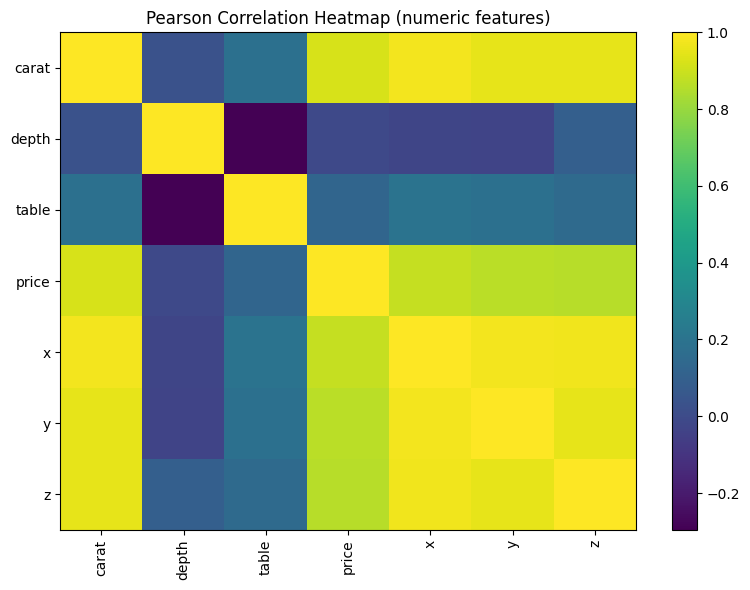

Top abs correlations with price:


,price
carat,0.921591
x,0.884435
y,0.865421
z,0.861249
table,0.127134
depth,0.010647


In [ ]:
# ----------------------------------------------Correlation Analysis-------------------------------------------#

# numeric columns only
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Pearson correlation
corr = df[num_cols].corr(method="pearson")

plt.figure(figsize=(8,6))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Pearson Correlation Heatmap (numeric features)")
plt.tight_layout()
plt.show()

# top absolute correlations with price (exclude price itself)
top_abs = corr["price"].drop("price").abs().sort_values(ascending=False)
print("Top abs correlations with price:")
display(top_abs)

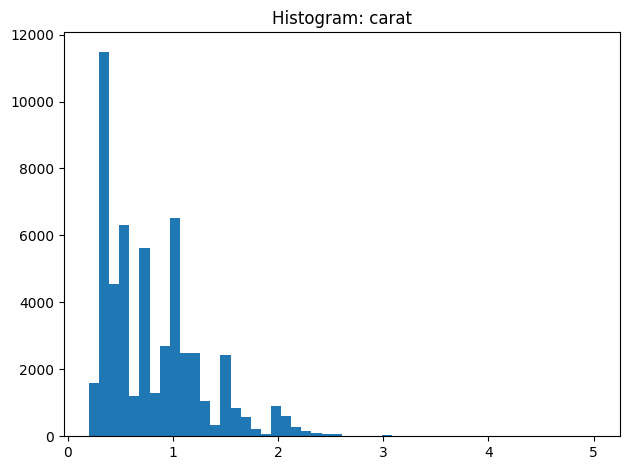

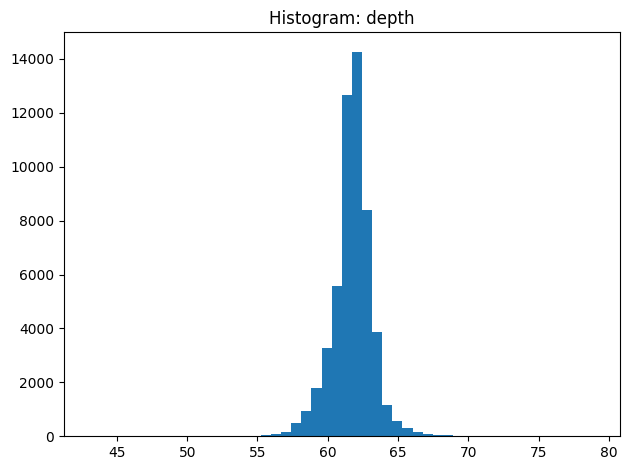

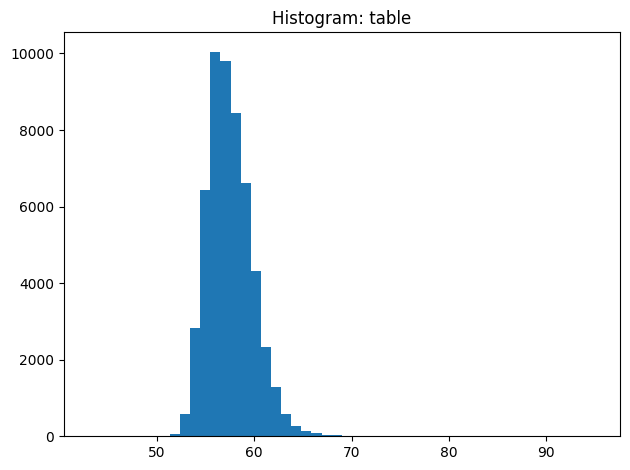

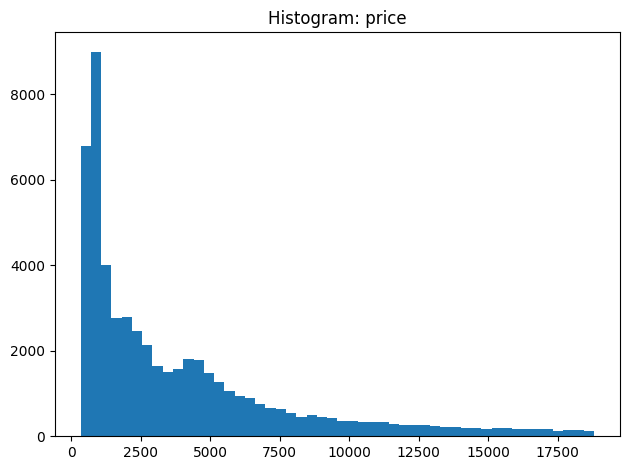

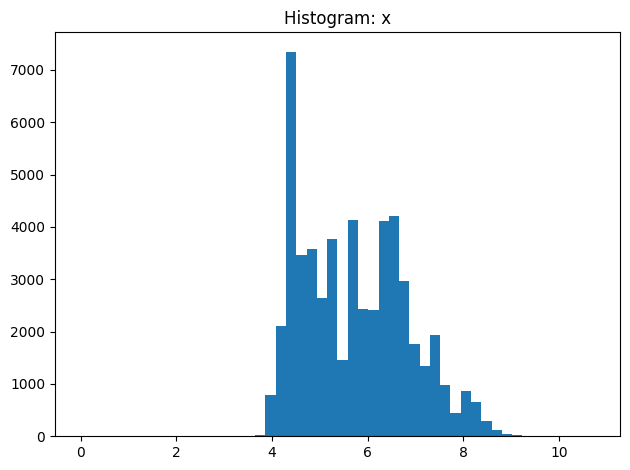

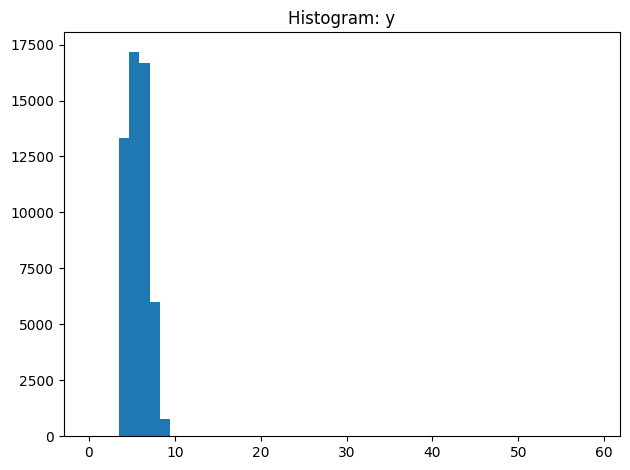

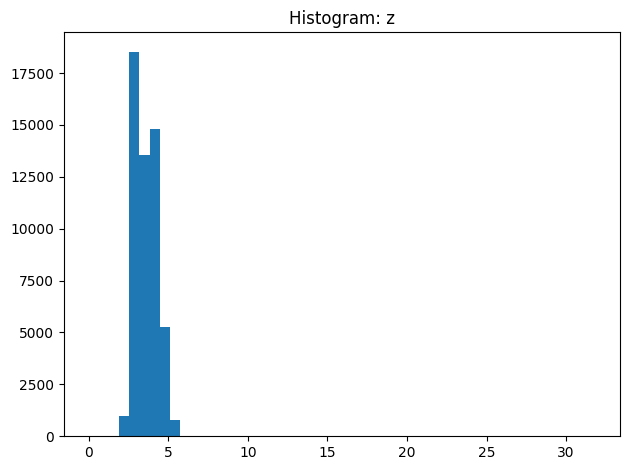

Skewness (sorted by |skew|):


,0
y,2.434167
price,1.618395
z,1.522423
carat,1.116646
table,0.796896
x,0.378676
depth,-0.082294


In [ ]:
#-------------------------------------------------Distribution Analysis--------------------------------------------#
# Histograms for numeric features
for c in num_cols:
    plt.figure()
    plt.hist(df[c].dropna(), bins=50)
    plt.title(f"Histogram: {c}")
    plt.tight_layout()
    plt.show()

# skewness
skew = df[num_cols].skew(numeric_only=True).sort_values(key=lambda s: s.abs(), ascending=False)
print("Skewness (sorted by |skew|):")
display(skew)

Categorical cols: ['cut', 'color', 'clarity']


<Figure size 800x400 with 0 Axes>

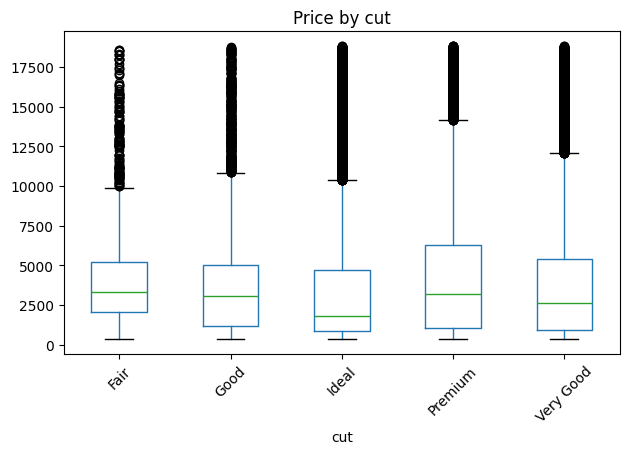

<Figure size 800x400 with 0 Axes>

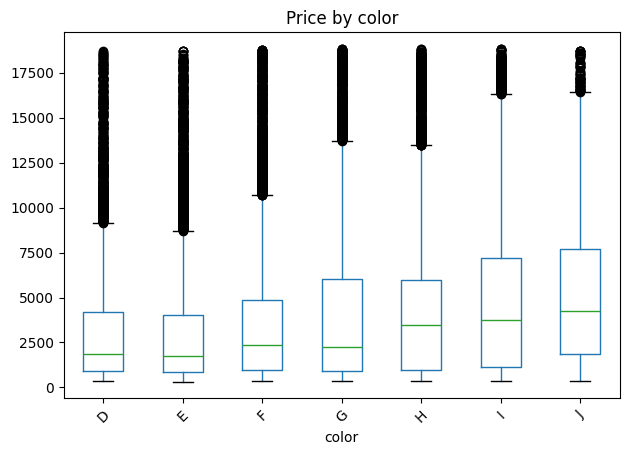

<Figure size 800x400 with 0 Axes>

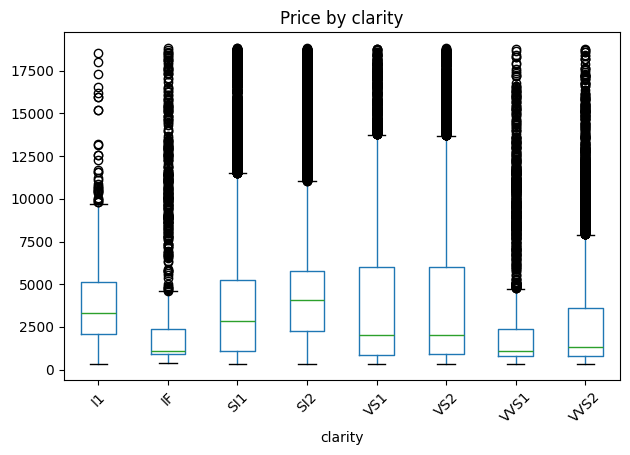

In [ ]:
#-------------------------------------------Categorical Analysis------------------------------------------------#
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Categorical cols:", cat_cols)

for c in cat_cols:
    plt.figure(figsize=(8,4))
    df.boxplot(column="price", by=c, grid=False)
    plt.title(f"Price by {c}")
    plt.suptitle("")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

QUESTION 22:

Explain the following trade-off questions.

1) Perform encoding for the categorical features in the Diamonds dataset. Report which method
you chose for each categorical feature and briefly explain your decision.
2) Explain the following trade-offs:

    – What information does one-hot encoding discard?

    – What assumption should hold strongly if we perform the scalar encoding instead?

ANSWER:

1) We encode the categorical features cut, color, and clarity using one-hot encoding. Although these categories have an intuitive ordering in diamond grading, using ordinal/scalar encoding would impose a single linear order and equal spacing between levels, which is a strong assumption and may be incorrect for a linear model. One-hot encoding avoids injecting an artificial numeric relationship between categories and allows the model to learn separate offsets for each category level.

2) Information lost by one-hot: one-hot does not explicitly represent any ordering or “distance” between levels (e.g., it does not encode that one grade is adjacent to another); each category becomes an independent indicator.

    Assumption for scalar/ordinal encoding: scalar encoding assumes the categories have a meaningful order and that treating successive categories as equally spaced numeric steps is reasonable (a linear model then assumes a single slope per +1 category).

In [ ]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

target = "price"

X = df.drop(columns=[target])
y = df[target].values

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)

preprocess_onehot = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="drop",
)

X_enc = preprocess_onehot.fit_transform(X)

# feature names (for later saving / feature selection)
ohe = preprocess_onehot.named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_cols)
feature_names = np.concatenate([num_cols, cat_feature_names])

print("Encoded X shape:", X_enc.shape)
print("Total features:", len(feature_names))
print("Example feature names:", feature_names[:20])

Numeric cols: ['carat', 'depth', 'table', 'x', 'y', 'z']
Categorical cols: ['cut', 'color', 'clarity']
Encoded X shape: (53940, 26)
Total features: 26
Example feature names: ['carat' 'depth' 'table' 'x' 'y' 'z' 'cut_Fair' 'cut_Good' 'cut_Ideal'
 'cut_Premium' 'cut_Very Good' 'color_D' 'color_E' 'color_F' 'color_G'
 'color_H' 'color_I' 'color_J' 'clarity_I1' 'clarity_IF']


QUESTION 23:

Standardize feature columns and prepare them for training. Save your standard-
ized version of the dataset as diamonds standardized.csv.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Standardize the encoded matrix
scaler = StandardScaler()
X_std = scaler.fit_transform(X_enc)

# Create standardized dataframe
df_std = pd.DataFrame(X_std, columns=feature_names)
df_std["price"] = y

out_path = "diamonds_standardized.csv"
df_std.to_csv(out_path, index=False)

print("Saved:", out_path)
print("Shape:", df_std.shape)
display(df_std.head())

Saved: diamonds_standardized.csv
Shape: (53940, 27)


,carat,depth,table,x,y,z,cut_Fair,cut_Good,cut_Ideal,cut_Premium,...,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2,price
0,-1.198168,-0.174092,-1.099672,-1.587837,-1.536196,-1.571129,-0.175403,-0.316312,1.225928,-0.586085,...,-0.234343,-0.11802,-0.185268,-0.565361,2.206098,-0.422524,-0.542295,-0.269603,-0.321954,326
1,-1.240361,-1.360738,1.585529,-1.641325,-1.658774,-1.741175,-0.175403,-0.316312,-0.815708,1.706238,...,-0.234343,-0.11802,-0.185268,1.768781,-0.453289,-0.422524,-0.542295,-0.269603,-0.321954,326
2,-1.198168,-3.385019,3.375663,-1.498691,-1.457395,-1.741175,-0.175403,3.161440,-0.815708,-0.586085,...,-0.234343,-0.11802,-0.185268,-0.565361,-0.453289,2.366727,-0.542295,-0.269603,-0.321954,327
3,-1.071587,0.454133,0.242928,-1.364971,-1.317305,-1.287720,-0.175403,-0.316312,-0.815708,1.706238,...,-0.234343,-0.11802,-0.185268,-0.565361,-0.453289,-0.422524,1.844015,-0.269603,-0.321954,334
4,-1.029394,1.082358,0.242928,-1.240167,-1.212238,-1.117674,-0.175403,3.161440,-0.815708,-0.586085,...,4.267248,-0.11802,-0.185268,-0.565361,2.206098,-0.422524,-0.542295,-0.269603,-0.321954,335


QUESTION 24:

Print the top 5 features using each method (mutual info regression and
f regression).


• Agentic Integration: For this step, load diamonds-questions.jsonl and diamonds-labels.jsonl
(question id 0 and 1) and use your ReAct agent from Part 2 to automatically identify and
print the top features. If the agent gets stuck, you may manually write the code to compute
and print them.

ANSWER:

For the agentic portion of Q24, I ran the ReAct agent on the Diamonds tasks with ids 0 and 1. The agent returned @top5_mi[carat, y, x, z, clarity_SI1] for the mutual-information ranking and @top5_f[carat, x, y, z, clarity_SI2] for the F-regression ranking. These results are consistent with the EDA in Q21, where size-related variables (carat and the physical dimensions x, y, z) showed the strongest relationship with price, and a clarity one-hot feature also appears among the top predictors. Although the agent’s outputs follow the required format, the provided diamonds-labels.jsonl contains empty reference answers for these items, so the automated correctness flag returns False despite producing a valid response.

In [ ]:
from sklearn.feature_selection import mutual_info_regression, f_regression

# Split standardized features/target
X_mat = df_std.drop(columns=["price"]).values
y_vec = df_std["price"].values
feat_names = df_std.drop(columns=["price"]).columns

# Mutual Information
mi = mutual_info_regression(X_mat, y_vec, random_state=0)
mi_series = pd.Series(mi, index=feat_names).sort_values(ascending=False)
mi_top5 = mi_series.head(5)

# F-regression
f_vals, p_vals = f_regression(X_mat, y_vec)
f_series = pd.Series(f_vals, index=feat_names).sort_values(ascending=False)
f_top5 = f_series.head(5)

print("Top 5 features by Mutual Information:")
display(mi_top5)

print("Top 5 features by F-regression (F-statistic):")
display(f_top5)

Top 5 features by Mutual Information:


,0
carat,1.962967
y,1.493710
x,1.481471
z,1.432914
clarity_SI1,0.091575


Top 5 features by F-regression (F-statistic):


,0
carat,304050.905940
x,193740.279068
y,160914.481807
z,154922.121058
clarity_SI2,904.449158


In [ ]:
selected_features = sorted(set(mi_top5.index.tolist() + f_top5.index.tolist()))
print("Selected features (union of top-5 MI and top-5 F):", selected_features)
print("Count:", len(selected_features))

df_selected = df_std[selected_features + ["price"]].copy()

out_path_sel = "diamonds_selected.csv"
df_selected.to_csv(out_path_sel, index=False)
print("Saved:", out_path_sel, "shape:", df_selected.shape)
display(df_selected.head())

Selected features (union of top-5 MI and top-5 F): ['carat', 'clarity_SI1', 'clarity_SI2', 'x', 'y', 'z']
Count: 6
Saved: diamonds_selected.csv shape: (53940, 7)


,carat,clarity_SI1,clarity_SI2,x,y,z,price
0,-1.198168,-0.565361,2.206098,-1.587837,-1.536196,-1.571129,326
1,-1.240361,1.768781,-0.453289,-1.641325,-1.658774,-1.741175,326
2,-1.198168,-0.565361,-0.453289,-1.498691,-1.457395,-1.741175,327
3,-1.071587,-0.565361,-0.453289,-1.364971,-1.317305,-1.287720,334
4,-1.029394,-0.565361,2.206098,-1.240167,-1.212238,-1.117674,335


In [ ]:
import os, json

# Paths (based on your Drive structure)
DIAMONDS_Q = os.path.join(DATA_DIR, "share_data", "diamonds-questions.jsonl")
DIAMONDS_L = os.path.join(DATA_DIR, "share_data", "diamonds-labels.jsonl")

def load_jsonl(path):
    with open(path, "r") as f:
        return [json.loads(line) for line in f]

diamonds_questions = load_jsonl(DIAMONDS_Q)
diamonds_labels = load_jsonl(DIAMONDS_L)

print("Loaded diamonds questions:", len(diamonds_questions))
print("Loaded diamonds labels:", len(diamonds_labels))
print("Sample question record keys:", diamonds_questions[0].keys())
print("Sample label record keys:", diamonds_labels[0].keys())

Loaded diamonds questions: 5
Loaded diamonds labels: 5
Sample question record keys: dict_keys(['id', 'question', 'concepts', 'constraints', 'format', 'file_name', 'level'])
Sample label record keys: dict_keys(['id', 'common_answers'])


In [ ]:
# Build by-id dicts (same pattern as Part B)
questions_by_id = {q["id"]: q for q in diamonds_questions}
labels_by_id = {l["id"]: l for l in diamonds_labels}

# sanity check
print("Diamond qids:", sorted(list(questions_by_id.keys())))

Diamond qids: [0, 1, 2, 3, 4]


In [ ]:
import os, shutil

src = "diamonds_standardized.csv"
dst = os.path.join(TABLES_DIR, "diamonds_standardized.csv")

print("src exists?", os.path.exists(src), src)
print("dst exists before?", os.path.exists(dst), dst)

shutil.copy(src, dst)

print("dst exists after?", os.path.exists(dst), dst)

src exists? True diamonds_standardized.csv
dst exists before? False /content/drive/MyDrive/ECE 219 Project 3/share_data/da-dev-tables/diamonds_standardized.csv
dst exists after? True /content/drive/MyDrive/ECE 219 Project 3/share_data/da-dev-tables/diamonds_standardized.csv


In [ ]:
print(res0.keys())

dict_keys(['qid', 'pred', 'true_parts', 'correct', 'history', 'final_plan'])


In [ ]:
print("Q0 true_parts:", res0["true_parts"])
print("Q1 true_parts:", res1["true_parts"])

Q0 true_parts: {'top5_mi': ''}
Q1 true_parts: {'top5_f': ''}


In [ ]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

target = "price"
X = df.drop(columns=[target])
y = df[target].values

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),  # scale numeric only
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),  # keep 0/1
    ],
    remainder="drop",
)

X_proc = preprocess.fit_transform(X)

# names
ohe = preprocess.named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_cols)
feature_names = np.concatenate([num_cols, cat_feature_names])

df_std2 = pd.DataFrame(X_proc, columns=feature_names)
df_std2["price"] = y

# save into working dir AND TABLES_DIR (so the agent finds it)
df_std2.to_csv("diamonds_standardized.csv", index=False)
df_std2.to_csv(os.path.join(TABLES_DIR, "diamonds_standardized.csv"), index=False)

print("Wrote diamonds_standardized.csv (numeric scaled only). Shape:", df_std2.shape)

Wrote diamonds_standardized.csv (numeric scaled only). Shape: (53940, 27)


In [ ]:
res0 = run_react_on_task(0, max_steps=5, verbose=False)
res1 = run_react_on_task(1, max_steps=5, verbose=False)
print("Q0 pred:", res0["pred"], "correct?", res0["correct"])
print("Q1 pred:", res1["pred"], "correct?", res1["correct"])
print("Q0 true_parts:", res0["true_parts"])
print("Q1 true_parts:", res1["true_parts"])

Q0 pred: @top5_mi[carat, y, x, z, clarity_SI1] correct? False
Q1 pred: @top5_f[carat, x, y, z, clarity_SI2] correct? False
Q0 true_parts: {'top5_mi': ''}
Q1 true_parts: {'top5_f': ''}


QUESTION 25:

Agentic Integration: For this step, load diamonds-questions.jsonl and
diamonds-labels.jsonl (question ids 2, 3, and 4) and use your ReAct agent from Part 2 to
automatically train the models and extract the necessary metrics. If the agent gets stuck, you may
manually write the code to complete the training.

ANSWER:

For OLS, the model is fit by minimizing the squared prediction errors. Ridge regression fits the model the same way but adds an L2 penalty term that shrinks coefficients toward zero (usually keeping all features). Lasso regression also fits by minimizing squared errors but adds an L1 penalty term, which can shrink some coefficients exactly to zero and therefore acts like feature selection. Using 10-fold cross validation on diamonds_selected.csv, the agent obtained OLS validation RMSE = 1418.19, Lasso best alpha = 0.0001 with validation RMSE = 1568.46, and Ridge best alpha = 0.0000 with validation RMSE = 1935.06 (so the best Ridge setting is effectively the unregularized model). Increasing alpha increases regularization strength: Ridge produces smaller, smoother coefficients, while Lasso becomes increasingly sparse by zeroing more coefficients. Finally, p-values in an OLS regression test whether each coefficient is significantly different from zero after accounting for the other features; smaller p-values indicate more statistically significant predictors, though multicollinearity can make these significance results unstable.

In [ ]:
for i in sorted(questions_by_id.keys()):
    print(i, "->", questions_by_id[i]["file_name"])

0 -> diamonds_standardized.csv
1 -> diamonds_standardized.csv
2 -> diamonds_selected.csv
3 -> diamonds_selected.csv
4 -> diamonds_selected.csv


In [ ]:
import os, shutil

src = "diamonds_selected.csv"
dst = os.path.join(TABLES_DIR, "diamonds_selected.csv")

print("src exists?", os.path.exists(src), src)
print("dst exists before?", os.path.exists(dst), dst)

shutil.copy(src, dst)

print("dst exists after?", os.path.exists(dst), dst)

src exists? True diamonds_selected.csv
dst exists before? False /content/drive/MyDrive/ECE 219 Project 3/share_data/da-dev-tables/diamonds_selected.csv
dst exists after? True /content/drive/MyDrive/ECE 219 Project 3/share_data/da-dev-tables/diamonds_selected.csv


In [ ]:
res2 = run_react_on_task(2, max_steps=8, verbose=True)
res3 = run_react_on_task(3, max_steps=8, verbose=True)
res4 = run_react_on_task(4, max_steps=8, verbose=True)

print("Q2 pred:", res2["pred"])
print("Q3 pred:", res3["pred"])
print("Q4 pred:", res4["pred"])


[QID 2] STEP 1 PLANNER: thought='I need to load the diamonds_selected.csv data and prepare it for training an OLS regression model. Next, I should perform 10-fold cross-validation to compute the average RMSE on the validation set.' is_done=False response="Load the diamonds_selected.csv file and extract the 'price' column as the target variable."

[QID 2] STEP 2 PLANNER: thought='The average RMSE from 10-fold cross-validation has already been computed and is available.' is_done=True response='@ols_val_rmse[1418.19]'

[QID 3] STEP 1 PLANNER: thought='I need to load the diamonds_selected.csv file and prepare the data for training a Lasso regression model using LassoCV. First, I should load the dataset and separate the features and target variable.' is_done=False response="Load the diamonds_selected.csv file and extract the 'price' column as the target variable, with all other columns as features."

[QID 3] STEP 2 PLANNER: thought='I have the best alpha and average validation RMSE from th

In [ ]:
def show_history_structure(res, n=2):
    print("keys:", res.keys())
    print("history len:", len(res["history"]))
    for i in range(min(n, len(res["history"]))):
        print(f"\n--- history[{i}] keys:", res["history"][i].keys())
        # print a small preview
        for k,v in res["history"][i].items():
            if isinstance(v, str):
                print(k, ":", v[:200])
            else:
                print(k, "type:", type(v))

show_history_structure(res2, n=1)

keys: dict_keys(['qid', 'pred', 'true_parts', 'correct', 'history', 'final_plan'])
history len: 1

--- history[0] keys: dict_keys(['step', 'plan', 'code', 'raw', 'obs'])
step type: <class 'int'>
plan type: <class '__main__.PlannerOutput'>
code : import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

# Load the dataset
csv_path = "/content/drive/MyDri
raw : @ols_val_rmse[1418.19]
obs type: <class '__main__.ObservationOutput'>


In [ ]:
#-------------------------------------------List out the Python code generated by your agent for these tasks.------------------------------#
def print_agent_code(res, title=""):
    print("\n" + "="*80)
    print(f"QID {res['qid']} {title}".strip())
    print("="*80)
    for h in res["history"]:
        code = h.get("code", "")
        if isinstance(code, str) and code.strip():
            print(code.strip())
            print()

print_agent_code(res2, "(OLS)")
print_agent_code(res3, "(Lasso)")
print_agent_code(res4, "(Ridge)")


QID 2 (OLS)
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

# Load the dataset
csv_path = "/content/drive/MyDrive/ECE 219 Project 3/share_data/da-dev-tables/diamonds_selected.csv"
df = pd.read_csv(csv_path)

# Separate features and target
X = df.drop(columns=['price'])
y = df['price']

# Initialize the model and perform 10-fold cross-validation
model = LinearRegression()
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

# Compute RMSE scores
rmse_scores = cross_val_score(model, X, y, cv=kfold, scoring='neg_mean_squared_error')

# Convert to positive and compute average RMSE
rmse_scores = np.sqrt(-rmse_scores)
avg_rmse = np.mean(rmse_scores)

# Round to two decimal places
rounded_rmse = round(avg_rmse, 2)

print("@ols_val_rmse[" + str(rounded_rmse) + "]")


QID 3 (Lasso)
import pandas as pd
from sklearn.linear_model import LassoCV
from sklearn.model_selection import cross_val_s